In [1]:
!pip install -r requirements.txt

  Using cached https://github.com/kpu/kenlm/archive/master.zip (553 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
ls

config/  drive/  emg2qwerty/  requirements.txt  sample_data/


In [3]:
from pathlib import Path
import os

CANDIDATES = [
    Path(r"c:\Users\Charlie Shang\OneDrive\桌面\学习相关\C247A\emg2qwerty-Detection"),  # Local Windows
    Path('/content/drive/MyDrive/emg2qwerty'),
    Path('/content/emg2qwerty'),
    Path('/Users/byte/Library/CloudStorage/GoogleDrive-zijiezh@g.ucla.edu/My Drive/emg2qwerty'),
]

REPO = next((p for p in CANDIDATES if p.exists()), None)
if REPO is None:
    raise FileNotFoundError(
        'Could not find repo. Checked:\n'
        + '\n'.join(str(p) for p in CANDIDATES)
        + '\n\nIf running in Colab, mount Drive first and verify folder name.'
    )

os.chdir(REPO)
print('Working directory:', Path.cwd())
print('Logs dir:', REPO / 'logs')

Working directory: /content/drive/MyDrive/emg2qwerty
Logs dir: /content/drive/MyDrive/emg2qwerty/logs


In [4]:
import importlib
import sys

required = [
    'hydra',
    'pytorch_lightning',
    'torch',
    'tensorboard',
]

missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print('Python:', sys.executable)
if missing:
    print('Missing packages:', missing)
    print('Install with: pip install -r requirements.txt && pip install -e .')
else:
    print('All required packages found.')

Python: /usr/bin/python3
All required packages found.


In [8]:
import os
import subprocess
import sys
from pathlib import Path
import time
from collections import deque

import yaml

requested_models = [
    'tds_conv_ctc',
    'recurrent_lstm_ctc',
    'recurrent_gru_ctc',
    'recurrent_rnn_ctc',
]
MODELS = [m for m in requested_models if (REPO / 'config' / 'model' / f'{m}.yaml').exists()]
missing_models = sorted(set(requested_models) - set(MODELS))
print('Models to run:', MODELS)
if missing_models:
    print('Skipping missing model configs:', missing_models)


def has_gpu() -> bool:
    try:
        import torch
        return bool(torch.cuda.is_available())
    except Exception:
        return False


def preflight_data_check() -> None:
    cfg_path = REPO / 'config' / 'user' / 'single_user.yaml'
    data_root = REPO / 'data'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing user split config: {cfg_path}')
    if not data_root.exists():
        raise FileNotFoundError(f'Missing data directory: {data_root}')

    cfg = yaml.safe_load(cfg_path.read_text())
    missing = []
    for split in ['train', 'val', 'test']:
        for item in cfg['dataset'][split]:
            session = item['session']
            hdf5_path = data_root / f'{session}.hdf5'
            if not hdf5_path.exists():
                missing.append(hdf5_path)

    if missing:
        preview = '\n'.join(str(p) for p in missing[:10])
        raise FileNotFoundError(
            f'Missing {len(missing)} data files under {data_root}. First 10:\n{preview}'
        )

    print('Preflight data check passed.')


accelerator = 'gpu' if has_gpu() else 'cpu'
MAX_EPOCHS = 40
AUTO_FALLBACK_TO_CPU = True

print('Using accelerator:', accelerator)
print('Max epochs per model:', MAX_EPOCHS)
preflight_data_check()


def run_dir_for(model_name: str, accel: str) -> Path:
    return REPO / 'logs' / 'architecture_experiment' / 'runs' / f'{model_name}_{accel}'


def build_args(model_name: str, accel: str):
    run_dir = run_dir_for(model_name, accel)
    return [
        'user=single_user',
        f'trainer.accelerator={accel}',
        'trainer.devices=1',
        f'trainer.max_epochs={MAX_EPOCHS}',
        '+trainer.enable_progress_bar=true',
        f'hydra.run.dir="{run_dir.as_posix()}"',
        'num_workers=0',
    ]


def run_with_live_output(cmd, log_file: Path):
    tail = deque(maxlen=120)
    env = os.environ.copy()
    env['HYDRA_FULL_ERROR'] = '1'
    env['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

    log_file.parent.mkdir(parents=True, exist_ok=True)
    with log_file.open('w', encoding='utf-8') as lf:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
            lf.write(line)
            tail.append(line.rstrip('\n'))

        ret = proc.wait()

    if ret != 0:
        print(f'\nFull log saved to: {log_file}')
        print('\n----- Last 120 log lines -----')
        print('\n'.join(tail))
        raise RuntimeError(f'Command failed with exit code {ret}')


def run_model(model_name: str, accel: str):
    run_dir = run_dir_for(model_name, accel)
    last_ckpt = run_dir / 'checkpoints' / 'last.ckpt'
    if last_ckpt.exists():
        print(f'Resuming from existing checkpoint: {last_ckpt}')

    cmd = [
        sys.executable,
        '-m',
        'emg2qwerty.train',
        f'model={model_name}',
        *build_args(model_name, accel),
    ]
    print('\nRunning:', ' '.join(cmd), flush=True)

    start = time.time()
    log_file = REPO / 'logs' / 'architecture_experiment' / f'{model_name}_{accel}.log'
    run_with_live_output(cmd, log_file=log_file)
    elapsed_min = (time.time() - start) / 60.0
    print(f'{model_name} completed successfully on {accel} in {elapsed_min:.1f} min.')


for i, model_name in enumerate(MODELS, start=1):
    print(f'\n===== Model {i}/{len(MODELS)}: {model_name} =====', flush=True)
    try:
        run_model(model_name, accelerator)
    except Exception as e:
        if accelerator == 'gpu' and AUTO_FALLBACK_TO_CPU:
            print(f'\nGPU run failed for {model_name}: {e}')
            print('Retrying once on CPU...')
            run_model(model_name, 'cpu')
        else:
            raise

print('\nAll architecture runs completed.')

Streaming output truncated to the last 5000 lines.
                                                                      
Epoch 9: 100%|██████████| 127/127 [00:36<00:00,  3.45it/s, loss=2.7, v_num=0]Epoch 9, global step 1200: 'val/CER' reached 98.80372 (best 98.80372), saving model to '/content/drive/MyDrive/emg2qwerty/logs/architecture_experiment/runs/tds_conv_ctc_gpu/checkpoints/epoch=9-step=1200.ckpt' as top 1

Epoch 10:  94%|█████████▍| 120/127 [00:35<00:02,  3.38it/s, loss=2.47, v_num=0]

Validation: 0it [00:00, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Validation DataLoader 0:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10: 100%|██████████| 127/127 [00:36<00:00,  3.44it/s, loss=2.47, v_num=0]

                                                                      
Epoch 10: 100%|██████████| 127/127 [00:36<00:00,  3.44it/s, loss=2.47, v_num=0]Epoch 10, global step 1320: 'val/CER' reached 96.27824 (best 96.27824), saving model to '/content/drive/MyDrive/emg2qwerty/

In [5]:
# Add new model names here. Each needs config/model/<name>.yaml
NEW_MODELS = ['recurrent_lstm_ctc_deep']

import os
import subprocess
import sys
import time
from collections import deque

new_models = [m for m in NEW_MODELS if (REPO / 'config' / 'model' / f'{m}.yaml').exists()]
missing = sorted(set(NEW_MODELS) - set(new_models))
if missing:
    print('Skipping missing configs:', missing)
if not new_models:
    print('No new models to run.')
else:
    try:
        import torch
        accel = 'gpu' if torch.cuda.is_available() else 'cpu'
    except Exception:
        accel = 'cpu'
    max_epochs = 40

    def run_dir_for(n, a): return REPO / 'logs' / 'architecture_experiment' / 'runs' / f'{n}_{a}'

    def run_with_live_output(cmd, log_file):
        tail = deque(maxlen=120)
        env = os.environ.copy()
        env['HYDRA_FULL_ERROR'] = '1'
        env['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
        log_file.parent.mkdir(parents=True, exist_ok=True)
        with log_file.open('w', encoding='utf-8') as lf:
            proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=env)
            for line in proc.stdout:
                print(line, end='')
                lf.write(line)
                tail.append(line.rstrip('\n'))
            ret = proc.wait()
        if ret != 0:
            print('\n'.join(tail))
            raise RuntimeError(f'Command failed with exit code {ret}')

    print('New models to run:', new_models, '| accelerator:', accel)
    for i, model_name in enumerate(new_models, start=1):
        print(f'\n===== New model {i}/{len(new_models)}: {model_name} =====', flush=True)
        run_dir = run_dir_for(model_name, accel)
        cmd = [sys.executable, '-m', 'emg2qwerty.train', f'model={model_name}', 'user=single_user',
               f'trainer.accelerator={accel}', 'trainer.devices=1', f'trainer.max_epochs={max_epochs}',
               '+trainer.enable_progress_bar=true', f'hydra.run.dir="{run_dir.as_posix()}"', 'num_workers=0']
        print('Running:', ' '.join(cmd), flush=True)
        start = time.time()
        run_with_live_output(cmd, REPO / 'logs' / 'architecture_experiment' / f'{model_name}_{accel}.log')
        print(f'{model_name} completed in {(time.time()-start)/60:.1f} min.')
    print('\nAll new model runs completed.')

New models to run: ['recurrent_lstm_ctc_deep'] | accelerator: gpu

===== New model 1/1: recurrent_lstm_ctc_deep =====
Running: /usr/bin/python3 -m emg2qwerty.train model=recurrent_lstm_ctc_deep user=single_user trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 +trainer.enable_progress_bar=true hydra.run.dir="/content/drive/MyDrive/emg2qwerty/logs/architecture_experiment/runs/recurrent_lstm_ctc_deep_gpu" num_workers=0
[2026-03-08 04:47:24,192][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
 

In [6]:
# Train LSTM variations: wide, shallow, unidirectional
# Requires: run cells 1–2 (REPO) and cell 3 (main training for helpers)

import os
import subprocess
import sys
import time
from pathlib import Path
from collections import deque

LSTM_VARIATIONS = [
    'recurrent_lstm_ctc_wide',
    'recurrent_lstm_ctc_shallow',
    'recurrent_lstm_ctc_unidirectional',
]
models = [m for m in LSTM_VARIATIONS if (REPO / 'config' / 'model' / f'{m}.yaml').exists()]
missing = sorted(set(LSTM_VARIATIONS) - set(models))
if missing:
    print('Skipping missing configs:', missing)
if not models:
    print('No LSTM variation models to run.')
else:
    try:
        import torch
        accel = 'gpu' if torch.cuda.is_available() else 'cpu'
    except Exception:
        accel = 'cpu'
    max_epochs = 40

    def run_dir_for(n, a): return REPO / 'logs' / 'architecture_experiment' / 'runs' / f'{n}_{a}'
    def run_with_live_output(cmd, log_file):
        tail = deque(maxlen=120)
        env = os.environ.copy()
        env['HYDRA_FULL_ERROR'] = '1'
        env['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
        log_file.parent.mkdir(parents=True, exist_ok=True)
        with log_file.open('w', encoding='utf-8') as lf:
            proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=env)
            for line in proc.stdout:
                print(line, end='')
                lf.write(line)
                tail.append(line.rstrip('\n'))
            ret = proc.wait()
        if ret != 0:
            print('\n'.join(tail))
            raise RuntimeError(f'Command failed with exit code {ret}')

    print('LSTM variations to run:', models, '| accelerator:', accel)
    for i, model_name in enumerate(models, start=1):
        print(f'\n===== LSTM var {i}/{len(models)}: {model_name} =====', flush=True)
        run_dir = run_dir_for(model_name, accel)
        cmd = [sys.executable, '-m', 'emg2qwerty.train', f'model={model_name}', 'user=single_user',
               f'trainer.accelerator={accel}', 'trainer.devices=1', f'trainer.max_epochs={max_epochs}',
               '+trainer.enable_progress_bar=true', f'hydra.run.dir="{run_dir.as_posix()}"', 'num_workers=0']
        print('Running:', ' '.join(cmd), flush=True)
        start = time.time()
        run_with_live_output(cmd, REPO / 'logs' / 'architecture_experiment' / f'{model_name}_{accel}.log')
        print(f'{model_name} completed in {(time.time()-start)/60:.1f} min.')
    print('\nLSTM variations completed.')

LSTM variations to run: ['recurrent_lstm_ctc_wide', 'recurrent_lstm_ctc_shallow', 'recurrent_lstm_ctc_unidirectional'] | accelerator: gpu

===== LSTM var 1/3: recurrent_lstm_ctc_wide =====
Running: /usr/bin/python3 -m emg2qwerty.train model=recurrent_lstm_ctc_wide user=single_user trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 +trainer.enable_progress_bar=true hydra.run.dir="/content/drive/MyDrive/emg2qwerty/logs/architecture_experiment/runs/recurrent_lstm_ctc_wide_gpu" num_workers=0
[2026-03-08 05:24:27,753][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystroke

In [8]:
# Train Transformer and CNN+RNN (experimental; may not converge)
# Requires: run cells 1–2 (REPO) and cell 3 (main training for helpers)

import os
import subprocess
import sys
import time
from pathlib import Path
from collections import deque

TRANSFORMER_CNNRNN = ['transformer_ctc', 'cnn_rnn_ctc']
models = [m for m in TRANSFORMER_CNNRNN if (REPO / 'config' / 'model' / f'{m}.yaml').exists()]
missing = sorted(set(TRANSFORMER_CNNRNN) - set(models))
if missing:
    print('Skipping missing configs:', missing)
if not models:
    print('No Transformer/CNN+RNN models to run.')
else:
    try:
        import torch
        accel = 'gpu' if torch.cuda.is_available() else 'cpu'
    except Exception:
        accel = 'cpu'
    max_epochs = 40

    def run_dir_for(n, a): return REPO / 'logs' / 'architecture_experiment' / 'runs' / f'{n}_{a}'
    def run_with_live_output(cmd, log_file):
        tail = deque(maxlen=120)
        env = os.environ.copy()
        env['HYDRA_FULL_ERROR'] = '1'
        env['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
        log_file.parent.mkdir(parents=True, exist_ok=True)
        with log_file.open('w', encoding='utf-8') as lf:
            proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=env)
            for line in proc.stdout:
                print(line, end='')
                lf.write(line)
                tail.append(line.rstrip('\n'))
            ret = proc.wait()
        if ret != 0:
            print('\n'.join(tail))
            raise RuntimeError(f'Command failed with exit code {ret}')

    print('Transformer & CNN+RNN to run:', models, '| accelerator:', accel)
    for i, model_name in enumerate(models, start=1):
        print(f'\n===== Model {i}/{len(models)}: {model_name} =====', flush=True)
        run_dir = run_dir_for(model_name, accel)
        cmd = [sys.executable, '-m', 'emg2qwerty.train', f'model={model_name}', 'user=single_user',
               f'trainer.accelerator={accel}', 'trainer.devices=1', f'trainer.max_epochs={max_epochs}',
               '+trainer.enable_progress_bar=true', f'hydra.run.dir="{run_dir.as_posix()}"', 'num_workers=0']
        print('Running:', ' '.join(cmd), flush=True)
        start = time.time()
        run_with_live_output(cmd, REPO / 'logs' / 'architecture_experiment' / f'{model_name}_{accel}.log')
        print(f'{model_name} completed in {(time.time()-start)/60:.1f} min.')
    print('\nTransformer & CNN+RNN runs completed.')

Transformer & CNN+RNN to run: ['transformer_ctc', 'cnn_rnn_ctc'] | accelerator: gpu

===== Model 1/2: transformer_ctc =====
Running: /usr/bin/python3 -m emg2qwerty.train model=transformer_ctc user=single_user trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 +trainer.enable_progress_bar=true hydra.run.dir="/content/drive/MyDrive/emg2qwerty/logs/architecture_experiment/runs/transformer_ctc_gpu" num_workers=0
[2026-03-08 07:33:14,807][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session

In [9]:
from pathlib import Path
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator


def latest_scalar(event_file: Path, tag: str):
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return None
    events = ea.Scalars(tag)
    return events[-1].value if events else None


def read_model_name(run_dir: Path) -> str:
    hydra_cfg = run_dir / 'hydra_configs' / 'overrides.yaml'
    if hydra_cfg.exists():
        for line in hydra_cfg.read_text().splitlines():
            if line.startswith('model='):
                return line.split('=', 1)[1]
    name = run_dir.name
    if name.endswith('_gpu'):
        return name[:-4]
    if name.endswith('_cpu'):
        return name[:-4]
    return 'unknown'


runs_root = REPO / 'logs' / 'architecture_experiment' / 'runs'
run_dirs = sorted([p for p in runs_root.glob('*') if p.is_dir()])
print(f'Found {len(run_dirs)} run dirs under {runs_root}')

rows = []
for run_dir in run_dirs:
    event_files = sorted(
        run_dir.glob('lightning_logs/**/events.out.tfevents.*'),
        key=lambda p: p.stat().st_mtime,
    )
    if not event_files:
        continue

    latest_event = event_files[-1]
    model_name = read_model_name(run_dir)

    rows.append(
        {
            'model': model_name,
            'run_dir': str(run_dir),
            'event_file': str(latest_event),
            'val_CER': latest_scalar(latest_event, 'val/CER'),
            'test_CER': latest_scalar(latest_event, 'test/CER'),
            'val_loss': latest_scalar(latest_event, 'val/loss'),
            'test_loss': latest_scalar(latest_event, 'test/loss'),
        }
    )

results_df = pd.DataFrame(rows)
if not results_df.empty:
    results_df = results_df.sort_values('test_CER', na_position='last').reset_index(drop=True)

results_df

Found 10 run dirs under /content/drive/MyDrive/emg2qwerty/logs/architecture_experiment/runs


,model,run_dir,event_file,val_CER,test_CER,val_loss,test_loss
0,recurrent_lstm_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,21.698725,None,0.694346
1,recurrent_lstm_ctc_wide,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,22.152582,None,0.698998
2,cnn_rnn_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,22.282257,None,0.679300
3,recurrent_gru_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,24.573158,None,0.756192
4,tds_conv_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,25.480873,None,0.812173
5,recurrent_lstm_ctc_shallow,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,30.041063,None,0.968956
6,recurrent_lstm_ctc_deep,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,39.226280,None,1.287886
7,recurrent_rnn_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,80.267990,None,1.648094
8,transformer_ctc,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,94.726608,None,2.919419
9,recurrent_lstm_ctc_unidirectional,/content/drive/MyDrive/emg2qwerty/logs/archite...,/content/drive/MyDrive/emg2qwerty/logs/archite...,None,100.000000,None,3.258295


In [10]:
# Save a compact summary CSV for your report.
out_csv = REPO / 'architecture_metrics_summary.csv'
results_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)

# Ranked view by test CER (lower is better)
results_df[['model', 'val_CER', 'test_CER', 'val_loss', 'test_loss']].sort_values('test_CER')

Saved: /content/drive/MyDrive/emg2qwerty/architecture_metrics_summary.csv


,model,val_CER,test_CER,val_loss,test_loss
0,recurrent_lstm_ctc,None,21.698725,None,0.694346
1,recurrent_lstm_ctc_wide,None,22.152582,None,0.698998
2,cnn_rnn_ctc,None,22.282257,None,0.679300
3,recurrent_gru_ctc,None,24.573158,None,0.756192
4,tds_conv_ctc,None,25.480873,None,0.812173
5,recurrent_lstm_ctc_shallow,None,30.041063,None,0.968956
6,recurrent_lstm_ctc_deep,None,39.226280,None,1.287886
7,recurrent_rnn_ctc,None,80.267990,None,1.648094
8,transformer_ctc,None,94.726608,None,2.919419
9,recurrent_lstm_ctc_unidirectional,None,100.000000,None,3.258295


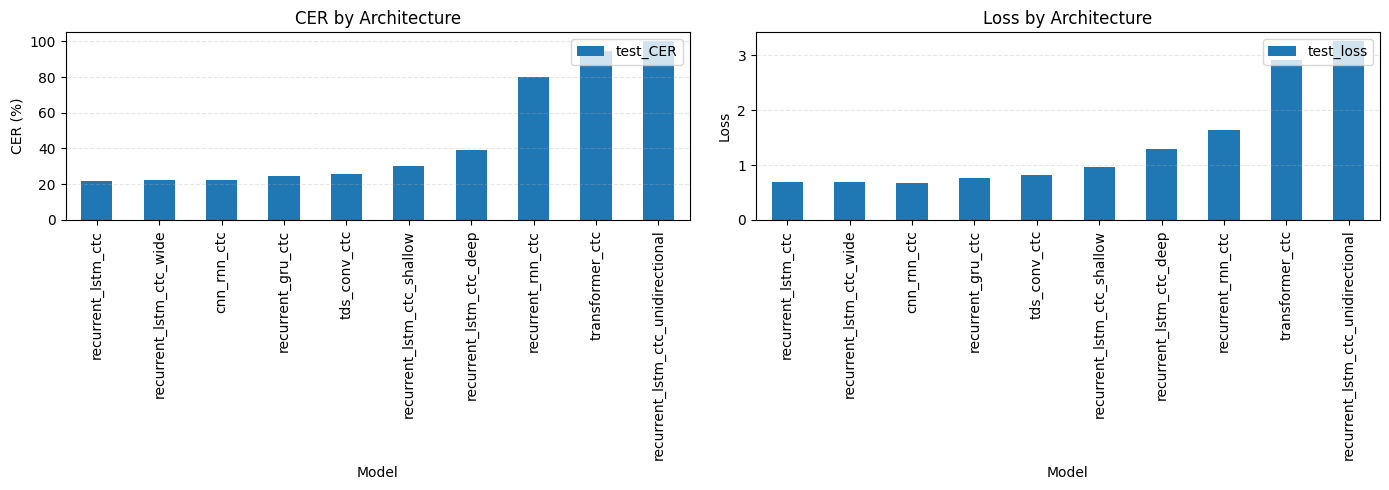

,model,val_CER,test_CER,val_loss,test_loss
0,recurrent_lstm_ctc,None,21.698725,None,0.694346
1,recurrent_lstm_ctc_wide,None,22.152582,None,0.698998
2,cnn_rnn_ctc,None,22.282257,None,0.679300
3,recurrent_gru_ctc,None,24.573158,None,0.756192
4,tds_conv_ctc,None,25.480873,None,0.812173
5,recurrent_lstm_ctc_shallow,None,30.041063,None,0.968956
6,recurrent_lstm_ctc_deep,None,39.226280,None,1.287886
7,recurrent_rnn_ctc,None,80.267990,None,1.648094
8,transformer_ctc,None,94.726608,None,2.919419
9,recurrent_lstm_ctc_unidirectional,None,100.000000,None,3.258295


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

if results_df.empty:
    print('No results to plot yet. Run training and the metrics cell first.')
else:
    plot_df = results_df.copy()

    plot_df = plot_df.dropna(subset=['model']).sort_values('test_CER', na_position='last')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cer_cols = ['val_CER', 'test_CER']
    cer_plot = plot_df.set_index('model')[cer_cols]
    cer_plot.plot(kind='bar', ax=axes[0])
    axes[0].set_title('CER by Architecture')
    axes[0].set_ylabel('CER (%)')
    axes[0].set_xlabel('Model')
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)
    axes[0].legend(loc='upper right')

    loss_cols = ['val_loss', 'test_loss']
    loss_plot = plot_df.set_index('model')[loss_cols]
    loss_plot.plot(kind='bar', ax=axes[1])
    axes[1].set_title('Loss by Architecture')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Model')
    axes[1].grid(axis='y', linestyle='--', alpha=0.3)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    display(plot_df[['model', 'val_CER', 'test_CER', 'val_loss', 'test_loss']])